# Course Project 3: Resampling and Model Selection Methods
## Dataset: Auto MPG (UCI Machine Learning Repository)
### Regression Task: Predicting Miles Per Gallon (MPG)

---
**Dataset Features:**
- `cylinders`: Number of cylinders
- `displacement`: Engine displacement (cubic inches)
- `horsepower`: Engine horsepower
- `weight`: Vehicle weight (lbs)
- `acceleration`: 0-60 mph time (seconds)
- `model_year`: Model year (mod 100)
- `origin`: Origin (1=USA, 2=Europe, 3=Japan)
- `mpg`: **Target variable** — fuel efficiency


---
## 📦 Part 0: Imports and Setup


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV, RidgeCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from itertools import combinations

# Plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C', '#E67E22']
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 🔍 Part 1: Data Loading & Preprocessing


In [3]:
# Load dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']
df = pd.read_csv(url, names=col_names, sep='\s+', na_values='?')
df.drop('car_name', axis=1, inplace=True)

print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
df.head()

Shape: (398, 8)

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [4]:
# Drop rows with missing values (6 in horsepower)
df.dropna(inplace=True)
df['horsepower'] = df['horsepower'].astype(float)
df.reset_index(drop=True, inplace=True)

print(f'Dataset shape after cleaning: {df.shape}')
df.describe()

Dataset shape after cleaning: (392, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


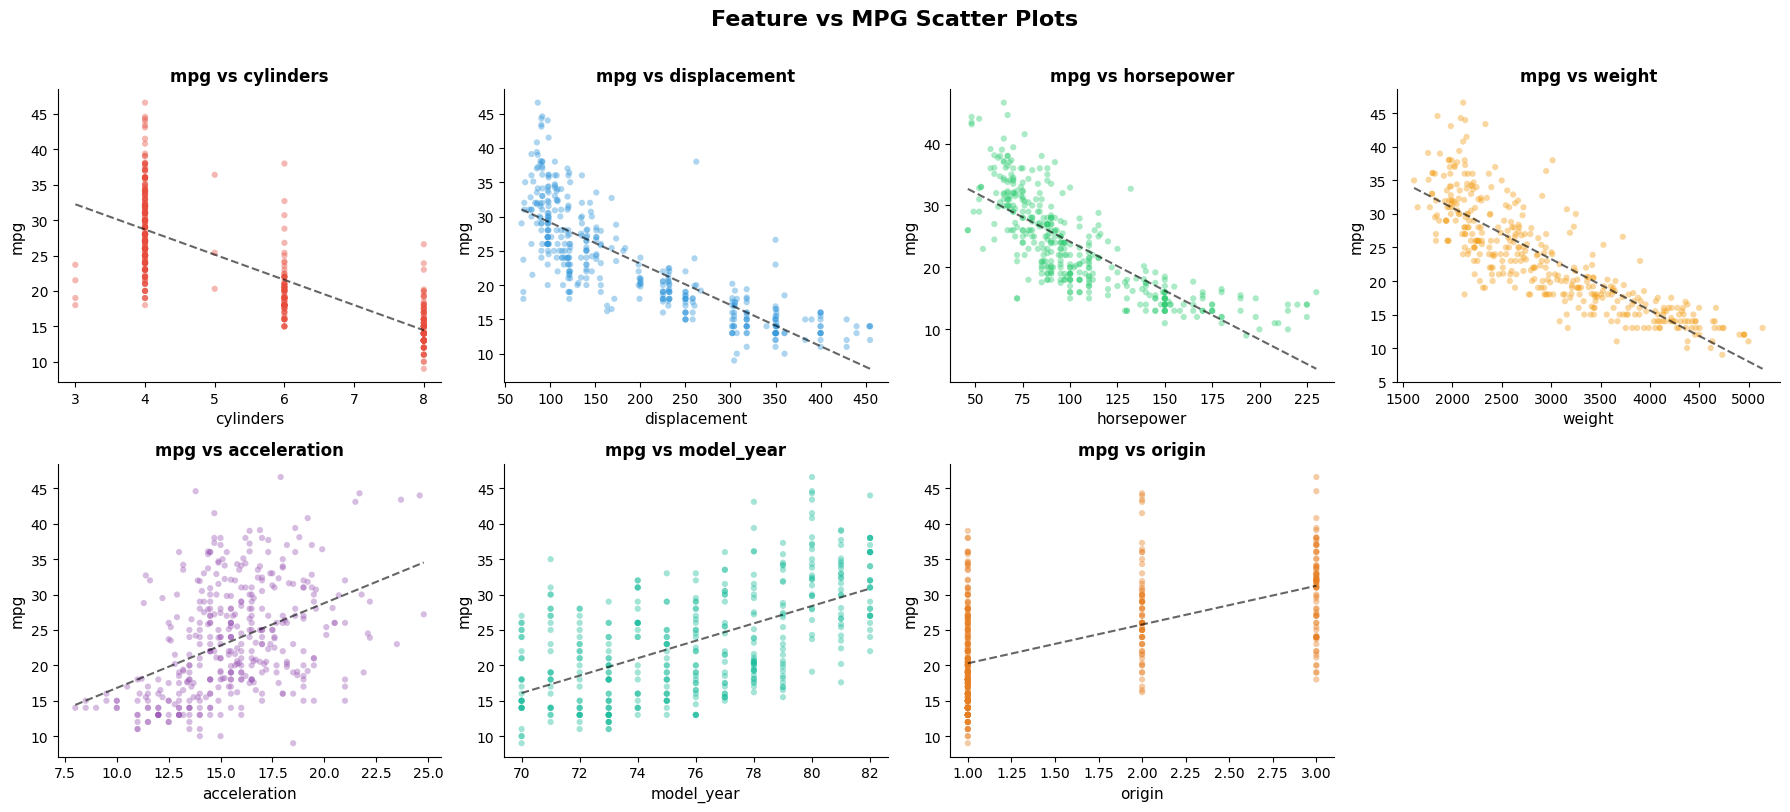

In [ ]:
# ─── Exploratory Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
features = ['cylinders','displacement','horsepower','weight','acceleration','model_year','origin']
for i, col in enumerate(features):
    ax = axes[i // 4][i % 4]
    ax.scatter(df[col], df['mpg'], alpha=0.4, color=COLORS[i], edgecolors='none', s=20)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('mpg', fontsize=11)
    ax.set_title(f'mpg vs {col}', fontsize=12, fontweight='bold')
    # Trend line
    z = np.polyfit(df[col], df['mpg'], 1)
    p = np.poly1d(z)
    xline = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(xline, p(xline), 'k--', alpha=0.6, linewidth=1.5)

axes[1][3].axis('off')
plt.suptitle('Feature vs MPG Scatter Plots', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./visualizations/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

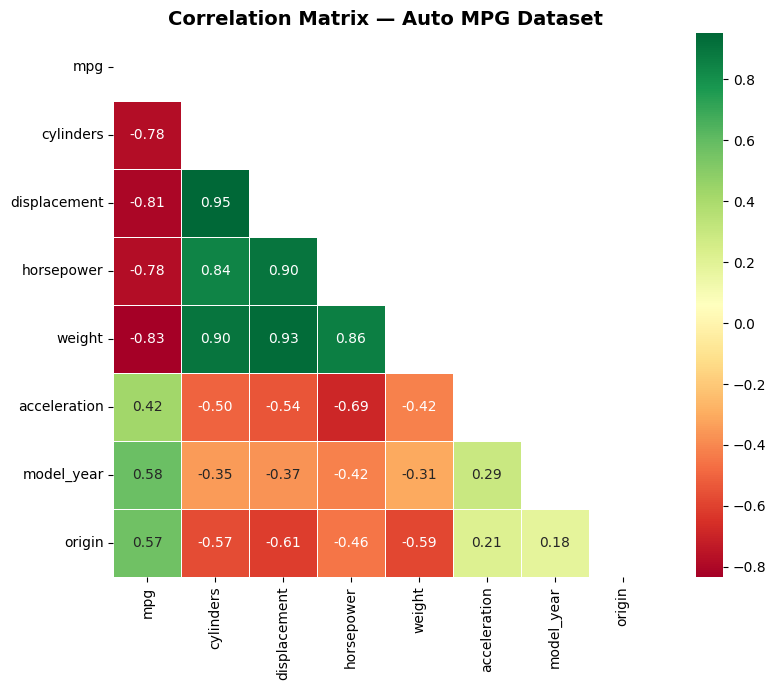

In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5, square=True)
ax.set_title('Correlation Matrix — Auto MPG Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./visualizations/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Prepare feature matrix and target
feature_cols = ['cylinders','displacement','horsepower','weight','acceleration','model_year','origin']
X = df[feature_cols].values
y = df['mpg'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'X shape: {X_scaled.shape}')
print(f'y shape: {y.shape}')

X shape: (392, 7)
y shape: (392,)


---
## 📊 Part 2: Resampling Methods

We evaluate **Polynomial Regression** (degrees 1–8) using:
- K-Fold Cross Validation (K=5, K=10, LOOCV)
- Bootstrap

The goal is to observe the **Bias-Variance tradeoff** across polynomial complexity.


### 2a. Cross Validation (K=5, K=10, LOOCV)


In [8]:
# Use single most correlated feature for clean polynomial demo
# (weight has highest correlation with mpg)
X_single = df[['weight']].values
y_cv = y.copy()

degrees = list(range(1, 9))
cv_results = {'k5': [], 'k10': [], 'loocv': []}

kf5   = KFold(n_splits=5,  shuffle=True, random_state=42)
kf10  = KFold(n_splits=10, shuffle=True, random_state=42)
loocv = LeaveOneOut()

for deg in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    mse_k5   = -cross_val_score(pipe, X_single, y_cv, cv=kf5,   scoring='neg_mean_squared_error').mean()
    mse_k10  = -cross_val_score(pipe, X_single, y_cv, cv=kf10,  scoring='neg_mean_squared_error').mean()
    mse_loocv= -cross_val_score(pipe, X_single, y_cv, cv=loocv, scoring='neg_mean_squared_error').mean()
    cv_results['k5'].append(mse_k5)
    cv_results['k10'].append(mse_k10)
    cv_results['loocv'].append(mse_loocv)
    print(f'Degree {deg}: K5={mse_k5:.2f}  K10={mse_k10:.2f}  LOOCV={mse_loocv:.2f}')

print('\n✅ Cross-validation complete!')

Degree 1: K5=18.93  K10=18.84  LOOCV=18.85
Degree 2: K5=17.57  K10=17.52  LOOCV=17.52
Degree 3: K5=17.61  K10=17.57  LOOCV=17.58
Degree 4: K5=17.63  K10=17.60  LOOCV=17.62
Degree 5: K5=17.69  K10=17.61  LOOCV=17.63
Degree 6: K5=17.77  K10=17.72  LOOCV=17.69
Degree 7: K5=17.77  K10=17.75  LOOCV=17.67
Degree 8: K5=17.76  K10=17.81  LOOCV=17.76

✅ Cross-validation complete!


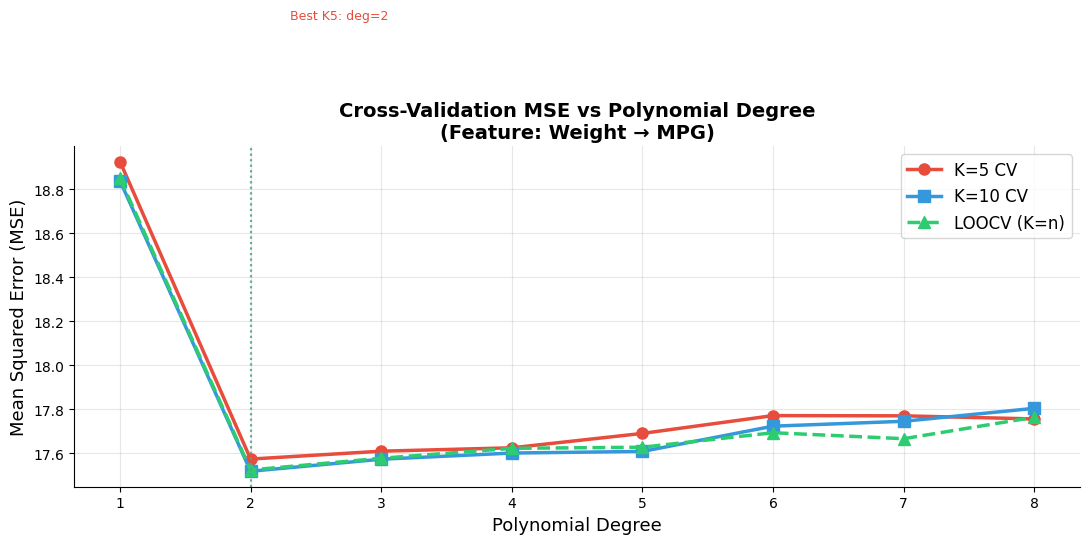

Best degree (K=5):   2
Best degree (K=10):  2
Best degree (LOOCV): 2


In [10]:
# ─── Plot CV MSE vs Polynomial Degree ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(degrees, cv_results['k5'],    'o-',  color='#E74C3C', lw=2.5, ms=8, label='K=5 CV')
ax.plot(degrees, cv_results['k10'],   's-',  color='#3498DB', lw=2.5, ms=8, label='K=10 CV')
ax.plot(degrees, cv_results['loocv'], '^--', color='#2ECC71', lw=2.5, ms=8, label='LOOCV (K=n)')

best_k5   = degrees[np.argmin(cv_results['k5'])]
best_k10  = degrees[np.argmin(cv_results['k10'])]
best_loocv= degrees[np.argmin(cv_results['loocv'])]

ax.axvline(best_k5,    color='#E74C3C', ls=':', alpha=0.5)
ax.axvline(best_k10,   color='#3498DB', ls=':', alpha=0.5)
ax.axvline(best_loocv, color='#2ECC71', ls=':', alpha=0.5)

ax.set_xlabel('Polynomial Degree', fontsize=13)
ax.set_ylabel('Mean Squared Error (MSE)', fontsize=13)
ax.set_title('Cross-Validation MSE vs Polynomial Degree\n(Feature: Weight → MPG)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(degrees)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Annotations
ax.annotate(f'Best K5: deg={best_k5}', xy=(best_k5, min(cv_results['k5'])),
            xytext=(best_k5+0.3, min(cv_results['k5'])+2), fontsize=9, color='#E74C3C')

plt.tight_layout()
plt.savefig('./visualizations/cv_mse_polynomial.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best degree (K=5):   {best_k5}')
print(f'Best degree (K=10):  {best_k10}')
print(f'Best degree (LOOCV): {best_loocv}')

### 2b. Bootstrap

Bootstrap resampling: we draw B=200 bootstrap samples (with replacement), fit the model, and evaluate on the **out-of-bag** samples.


In [11]:
def bootstrap_mse(X, y, degree, n_bootstraps=200, random_state=42):
    """Bootstrap estimate of MSE for polynomial regression."""
    rng = np.random.RandomState(random_state)
    n = len(y)
    mse_list = []
    for _ in range(n_bootstraps):
        idx_boot = rng.choice(n, n, replace=True)
        idx_oob  = list(set(range(n)) - set(idx_boot))
        if len(idx_oob) == 0:
            continue
        X_train, y_train = X[idx_boot], y[idx_boot]
        X_test,  y_test  = X[idx_oob],  y[idx_oob]
        pipe = Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('lr', LinearRegression())
        ])
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        mse_list.append(mean_squared_error(y_test, preds))
    return np.mean(mse_list), np.std(mse_list)

bootstrap_mses  = []
bootstrap_stds  = []
for deg in degrees:
    m, s = bootstrap_mse(X_single, y_cv, deg)
    bootstrap_mses.append(m)
    bootstrap_stds.append(s)
    print(f'Degree {deg}: Bootstrap MSE = {m:.2f} ± {s:.2f}')

best_boot = degrees[np.argmin(bootstrap_mses)]
print(f'\n✅ Best degree (Bootstrap): {best_boot}')

Degree 1: Bootstrap MSE = 18.75 ± 2.09
Degree 2: Bootstrap MSE = 17.45 ± 2.13
Degree 3: Bootstrap MSE = 17.53 ± 2.14
Degree 4: Bootstrap MSE = 17.60 ± 2.14
Degree 5: Bootstrap MSE = 17.65 ± 2.15
Degree 6: Bootstrap MSE = 17.77 ± 2.10
Degree 7: Bootstrap MSE = 17.78 ± 2.12
Degree 8: Bootstrap MSE = 18.00 ± 2.24

✅ Best degree (Bootstrap): 2


### 2c. Plot MSE vs Polynomial Degree: CV vs Bootstrap


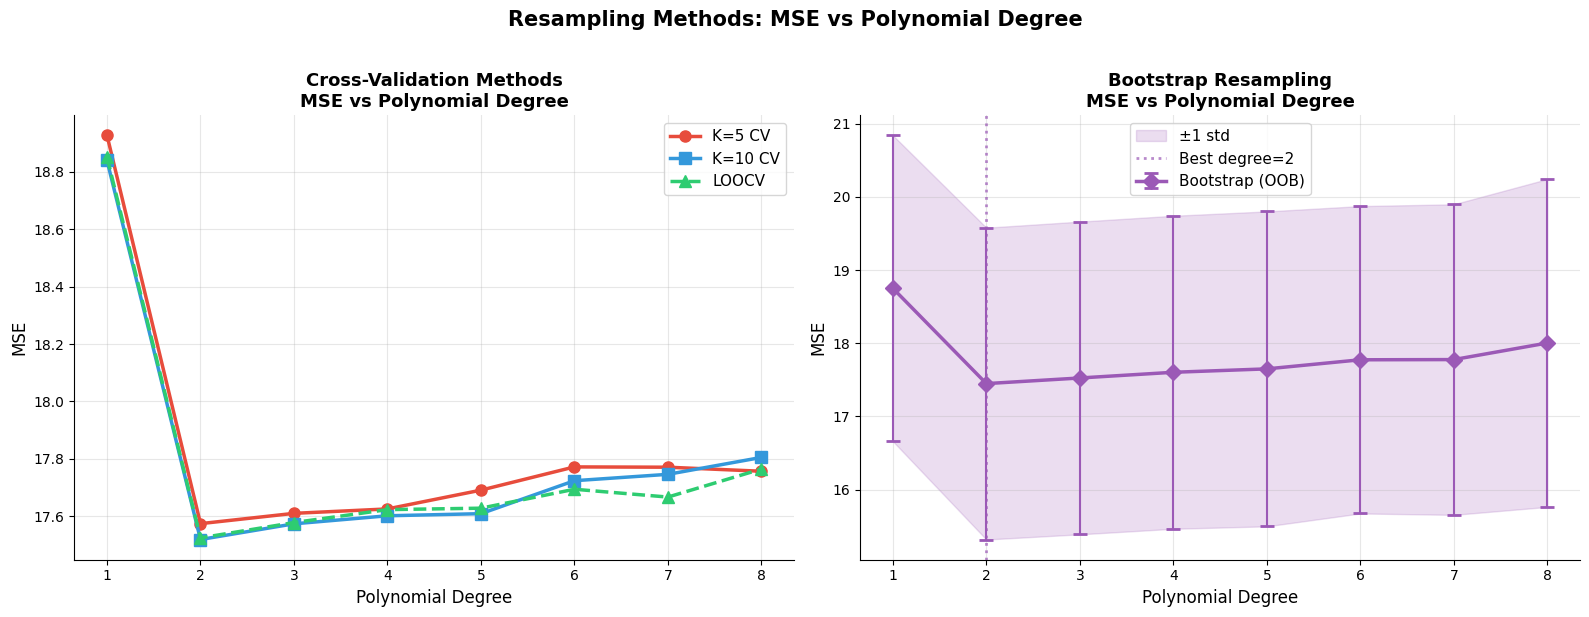

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: All CV methods
ax = axes[0]
ax.plot(degrees, cv_results['k5'],    'o-',  color='#E74C3C', lw=2.5, ms=8, label='K=5 CV')
ax.plot(degrees, cv_results['k10'],   's-',  color='#3498DB', lw=2.5, ms=8, label='K=10 CV')
ax.plot(degrees, cv_results['loocv'], '^--', color='#2ECC71', lw=2.5, ms=8, label='LOOCV')
ax.set_xlabel('Polynomial Degree', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('Cross-Validation Methods\nMSE vs Polynomial Degree', fontsize=13, fontweight='bold')
ax.set_xticks(degrees)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Right: Bootstrap with error bars
ax = axes[1]
ax.errorbar(degrees, bootstrap_mses, yerr=bootstrap_stds,
            fmt='D-', color='#9B59B6', lw=2.5, ms=8, capsize=5,
            capthick=2, elinewidth=1.5, label='Bootstrap (OOB)')
ax.fill_between(degrees,
                np.array(bootstrap_mses)-np.array(bootstrap_stds),
                np.array(bootstrap_mses)+np.array(bootstrap_stds),
                alpha=0.2, color='#9B59B6', label='±1 std')
ax.axvline(best_boot, color='#9B59B6', ls=':', lw=2, alpha=0.7,
           label=f'Best degree={best_boot}')
ax.set_xlabel('Polynomial Degree', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('Bootstrap Resampling\nMSE vs Polynomial Degree', fontsize=13, fontweight='bold')
ax.set_xticks(degrees)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.suptitle('Resampling Methods: MSE vs Polynomial Degree', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./visualizations/resampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎯 Part 3: Model Selection Methods

### 3a. Subset Selection (Best Subset, Forward, Backward)


In [13]:
def compute_metrics(X_cols, X_data, y_data):
    """Compute Cp, AIC, BIC, Adj-R2 for a given feature subset."""
    X_sub = sm.add_constant(X_data[:, X_cols])
    model = sm.OLS(y_data, X_sub).fit()
    n, k = len(y_data), len(X_cols)
    sigma2 = np.var(y_data - model.fittedvalues, ddof=1)
    # Full model sigma2 (for Cp)
    X_full = sm.add_constant(X_data)
    full_model = sm.OLS(y_data, X_full).fit()
    sigma2_full = np.sum(full_model.resid**2) / (n - X_data.shape[1] - 1)
    
    rss  = np.sum(model.resid**2)
    cp   = (rss + 2*k*sigma2_full) / n
    aic  = model.aic
    bic  = model.bic
    adjr2= model.rsquared_adj
    mse  = rss / n
    return {'cp': cp, 'aic': aic, 'bic': bic, 'adjr2': adjr2, 'mse': mse, 'cols': X_cols}

# Best Subset Selection
p = X_scaled.shape[1]  # 7 features
best_subset_results = []

for k in range(1, p+1):
    best_k = None
    for subset in combinations(range(p), k):
        res = compute_metrics(list(subset), X_scaled, y)
        if best_k is None or res['mse'] < best_k['mse']:
            best_k = res
    best_subset_results.append(best_k)
    print(f'k={k}: AIC={best_k["aic"]:.1f}  BIC={best_k["bic"]:.1f}  '
          f'Cp={best_k["cp"]:.2f}  AdjR2={best_k["adjr2"]:.4f}  '
          f'Cols={[feature_cols[c] for c in best_k["cols"]]}')

print('\n✅ Best Subset Selection complete!')

k=1: AIC=2263.9  BIC=2271.9  Cp=18.73  AdjR2=0.6918  Cols=['weight']
k=2: AIC=2081.1  BIC=2093.0  Cp=11.77  AdjR2=0.8072  Cols=['weight', 'model_year']
k=3: AIC=2063.7  BIC=2079.6  Cp=11.26  AdjR2=0.8160  Cols=['weight', 'model_year', 'origin']
k=4: AIC=2064.3  BIC=2084.2  Cp=11.28  AdjR2=0.8162  Cols=['displacement', 'weight', 'model_year', 'origin']
k=5: AIC=2062.1  BIC=2086.0  Cp=11.22  AdjR2=0.8177  Cols=['displacement', 'horsepower', 'weight', 'model_year', 'origin']
k=6: AIC=2061.6  BIC=2089.4  Cp=11.21  AdjR2=0.8184  Cols=['cylinders', 'displacement', 'horsepower', 'weight', 'model_year', 'origin']
k=7: AIC=2062.9  BIC=2094.7  Cp=11.24  AdjR2=0.8182  Cols=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']

✅ Best Subset Selection complete!


In [14]:
# Forward Stepwise Selection
def forward_stepwise(X_data, y_data, feature_names):
    remaining = list(range(X_data.shape[1]))
    selected  = []
    results   = []
    while remaining:
        best = None
        for feat in remaining:
            trial = selected + [feat]
            r = compute_metrics(trial, X_data, y_data)
            if best is None or r['aic'] < best['aic']:
                best = r
                best_feat = feat
        selected.append(best_feat)
        remaining.remove(best_feat)
        results.append(best)
    return results

def backward_stepwise(X_data, y_data, feature_names):
    selected = list(range(X_data.shape[1]))
    results  = [compute_metrics(selected, X_data, y_data)]
    while len(selected) > 1:
        best = None
        for feat in selected:
            trial = [f for f in selected if f != feat]
            r = compute_metrics(trial, X_data, y_data)
            if best is None or r['aic'] < best['aic']:
                best = r
                worst_feat = feat
        selected.remove(worst_feat)
        results.append(best)
    return results[::-1]  # order by number of features

fwd_results = forward_stepwise(X_scaled, y, feature_cols)
bwd_results = backward_stepwise(X_scaled, y, feature_cols)
print('✅ Stepwise selection complete!')

✅ Stepwise selection complete!


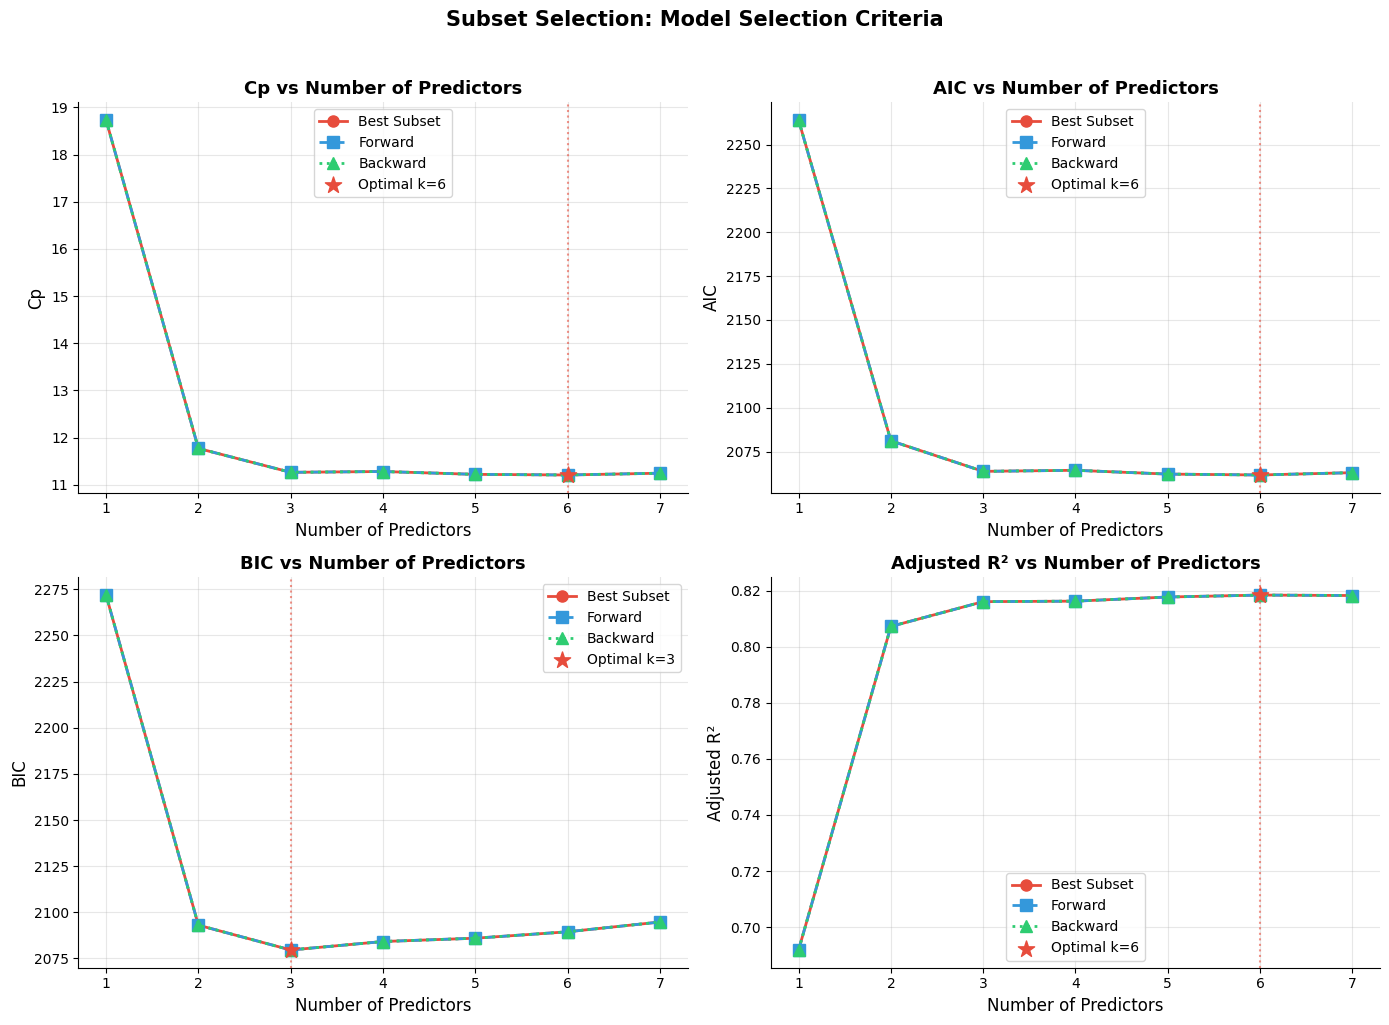

In [15]:
# ─── Subset Selection Plots ───────────────────────────────────────────────────
metrics = ['cp', 'aic', 'bic', 'adjr2']
metric_labels = ['Cp', 'AIC', 'BIC', 'Adjusted R²']
best_funcs = [np.argmin, np.argmin, np.argmin, np.argmax]  # adjr2 → maximize

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
k_vals = list(range(1, p+1))

for i, (metric, label, bf) in enumerate(zip(metrics, metric_labels, best_funcs)):
    ax = axes[i//2][i%2]
    
    best_vals = [r[metric] for r in best_subset_results]
    fwd_vals  = [r[metric] for r in fwd_results]
    bwd_vals  = [r[metric] for r in bwd_results]
    
    ax.plot(k_vals, best_vals, 'o-',  color='#E74C3C', lw=2, ms=8, label='Best Subset')
    ax.plot(k_vals, fwd_vals,  's--', color='#3498DB', lw=2, ms=8, label='Forward')
    ax.plot(k_vals, bwd_vals,  '^:',  color='#2ECC71', lw=2, ms=8, label='Backward')
    
    best_k = bf(best_vals) + 1
    ax.axvline(best_k, color='#E74C3C', ls=':', alpha=0.6)
    ax.scatter([best_k], [best_vals[best_k-1]], color='#E74C3C', s=150, zorder=5, 
               marker='*', label=f'Optimal k={best_k}')
    
    ax.set_xlabel('Number of Predictors', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'{label} vs Number of Predictors', fontsize=13, fontweight='bold')
    ax.set_xticks(k_vals)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Subset Selection: Model Selection Criteria', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./visualizations/subset_selection.png', dpi=150, bbox_inches='tight')
plt.show()

Best k by 10-fold CV: 4


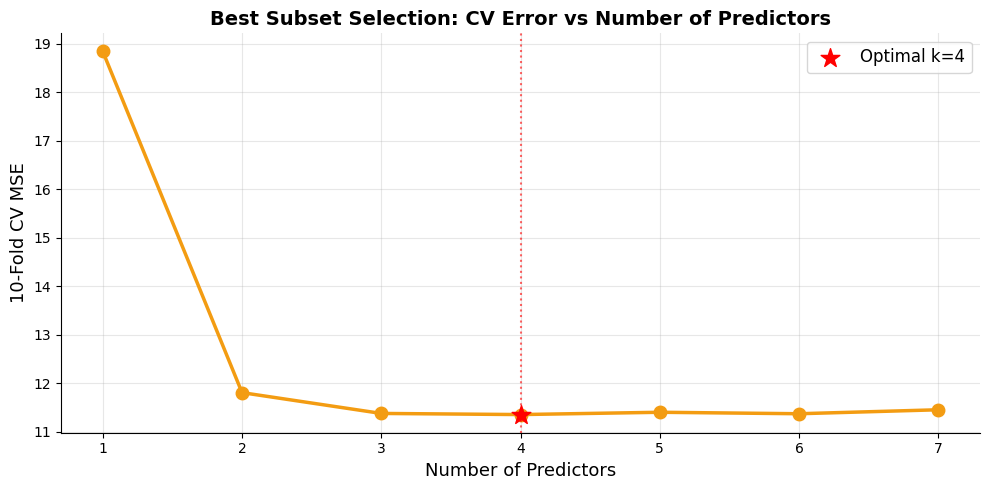

In [16]:
# CV-based selection for subset
cv_subset_mses = []
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for res in best_subset_results:
    X_sub = X_scaled[:, res['cols']]
    lr = LinearRegression()
    mse_cv = -cross_val_score(lr, X_sub, y, cv=kf, scoring='neg_mean_squared_error').mean()
    cv_subset_mses.append(mse_cv)

best_cv_k = np.argmin(cv_subset_mses) + 1
print(f'Best k by 10-fold CV: {best_cv_k}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_vals, cv_subset_mses, 'o-', color='#F39C12', lw=2.5, ms=9)
ax.scatter([best_cv_k], [cv_subset_mses[best_cv_k-1]], color='red', s=200, zorder=5,
           marker='*', label=f'Optimal k={best_cv_k}')
ax.axvline(best_cv_k, color='red', ls=':', alpha=0.6)
ax.set_xlabel('Number of Predictors', fontsize=13)
ax.set_ylabel('10-Fold CV MSE', fontsize=13)
ax.set_title('Best Subset Selection: CV Error vs Number of Predictors', fontsize=14, fontweight='bold')
ax.set_xticks(k_vals)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./visualizations/subset_cv.png', dpi=150, bbox_inches='tight')
plt.show()

### 3b. Shrinkage Methods: Ridge and Lasso

We apply Ridge and Lasso regression and visualize:
- Coefficient paths vs λ
- Bias-Variance tradeoff
- CV error vs λ


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Ridge
alphas_ridge = np.logspace(-3, 5, 200)
ridge_coefs, ridge_train_mse, ridge_test_mse = [], [], []

for alpha in alphas_ridge:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)
    ridge_train_mse.append(mean_squared_error(y_train, ridge.predict(X_train)))
    ridge_test_mse.append(mean_squared_error(y_test, ridge.predict(X_test)))

ridge_coefs = np.array(ridge_coefs)

# Lasso
alphas_lasso = np.logspace(-3, 1, 200)
lasso_coefs, lasso_train_mse, lasso_test_mse = [], [], []

for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_coefs.append(lasso.coef_)
    lasso_train_mse.append(mean_squared_error(y_train, lasso.predict(X_train)))
    lasso_test_mse.append(mean_squared_error(y_test, lasso.predict(X_test)))

lasso_coefs = np.array(lasso_coefs)
print('✅ Ridge & Lasso coefficient paths computed!')

✅ Ridge & Lasso coefficient paths computed!


In [18]:
# Find optimal lambdas via CV
ridge_cv = RidgeCV(alphas=alphas_ridge, cv=10)
ridge_cv.fit(X_scaled, y)
opt_ridge_alpha = ridge_cv.alpha_

lasso_cv = LassoCV(alphas=alphas_lasso, cv=10, max_iter=10000, random_state=42)
lasso_cv.fit(X_scaled, y)
opt_lasso_alpha = lasso_cv.alpha_

print(f'Optimal Ridge λ: {opt_ridge_alpha:.4f}')
print(f'Optimal Lasso λ: {opt_lasso_alpha:.4f}')

Optimal Ridge λ: 0.0010
Optimal Lasso λ: 0.0010


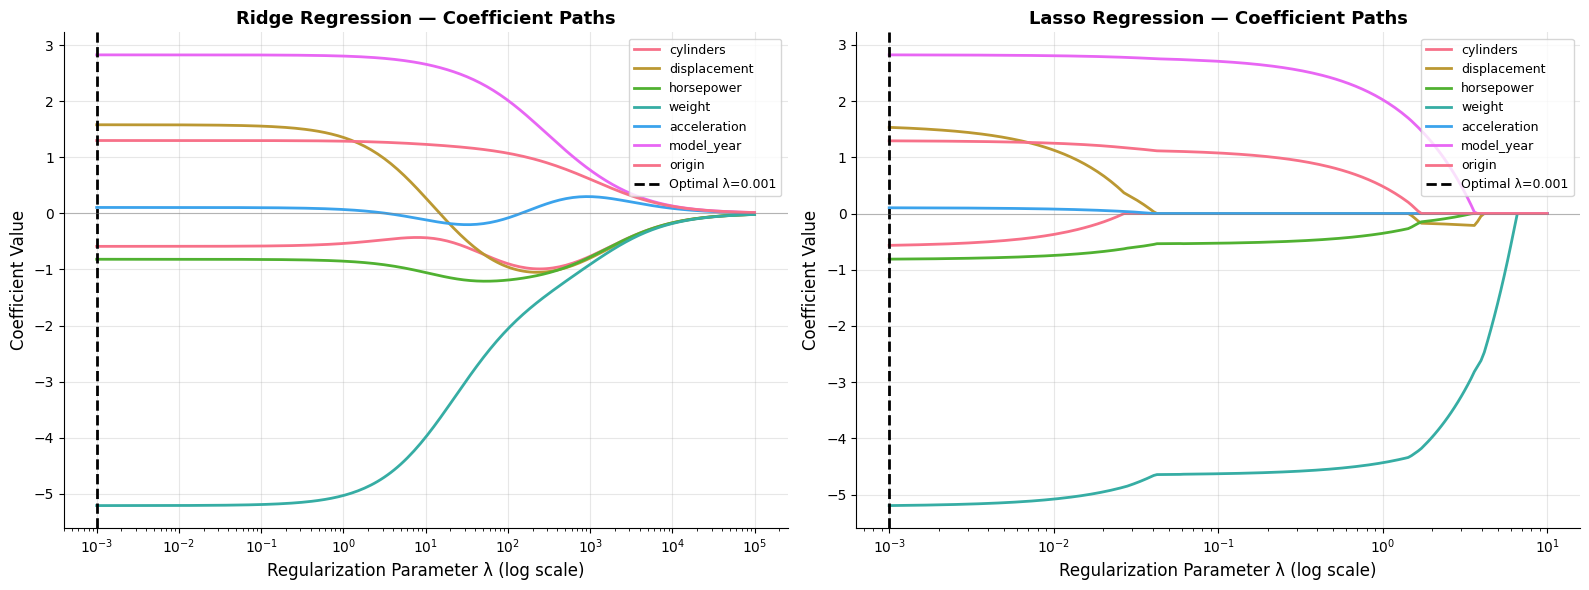

In [19]:
# ─── Coefficient Paths ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, coefs, alphas, opt_alpha, title in zip(
    axes,
    [ridge_coefs, lasso_coefs],
    [alphas_ridge, alphas_lasso],
    [opt_ridge_alpha, opt_lasso_alpha],
    ['Ridge', 'Lasso']):
    
    for j, feat in enumerate(feature_cols):
        ax.semilogx(alphas, coefs[:, j], lw=2, label=feat)
    
    ax.axvline(opt_alpha, color='black', ls='--', lw=2, label=f'Optimal λ={opt_alpha:.3f}')
    ax.axhline(0, color='gray', ls='-', lw=0.8, alpha=0.5)
    ax.set_xlabel('Regularization Parameter λ (log scale)', fontsize=12)
    ax.set_ylabel('Coefficient Value', fontsize=12)
    ax.set_title(f'{title} Regression — Coefficient Paths', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./visualizations/shrinkage_coef_paths.png', dpi=150, bbox_inches='tight')
plt.show()

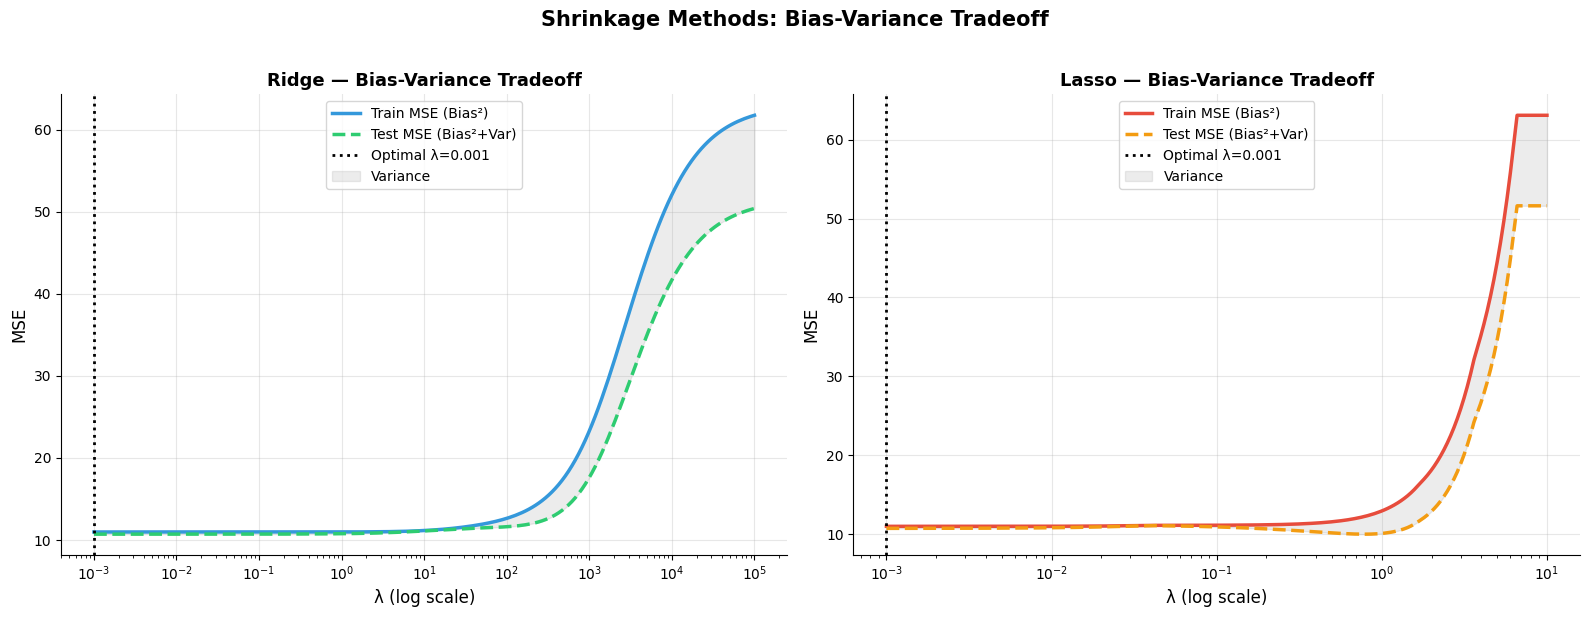

In [20]:
# ─── Bias-Variance Tradeoff ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, train_mse, test_mse, alphas, opt_alpha, title, color_train, color_test in zip(
    axes,
    [ridge_train_mse, lasso_train_mse],
    [ridge_test_mse, lasso_test_mse],
    [alphas_ridge, alphas_lasso],
    [opt_ridge_alpha, opt_lasso_alpha],
    ['Ridge', 'Lasso'],
    ['#3498DB', '#E74C3C'],
    ['#2ECC71', '#F39C12']):

    ax.semilogx(alphas, train_mse, '-',  color=color_train, lw=2.5, label='Train MSE (Bias²)')
    ax.semilogx(alphas, test_mse,  '--', color=color_test,  lw=2.5, label='Test MSE (Bias²+Var)')
    ax.axvline(opt_alpha, color='black', ls=':', lw=2, label=f'Optimal λ={opt_alpha:.3f}')
    
    # Shade variance region
    ax.fill_between(alphas, train_mse, test_mse, alpha=0.15, color='gray', label='Variance')
    
    ax.set_xlabel('λ (log scale)', fontsize=12)
    ax.set_ylabel('MSE', fontsize=12)
    ax.set_title(f'{title} — Bias-Variance Tradeoff', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Shrinkage Methods: Bias-Variance Tradeoff', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./visualizations/bias_variance_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

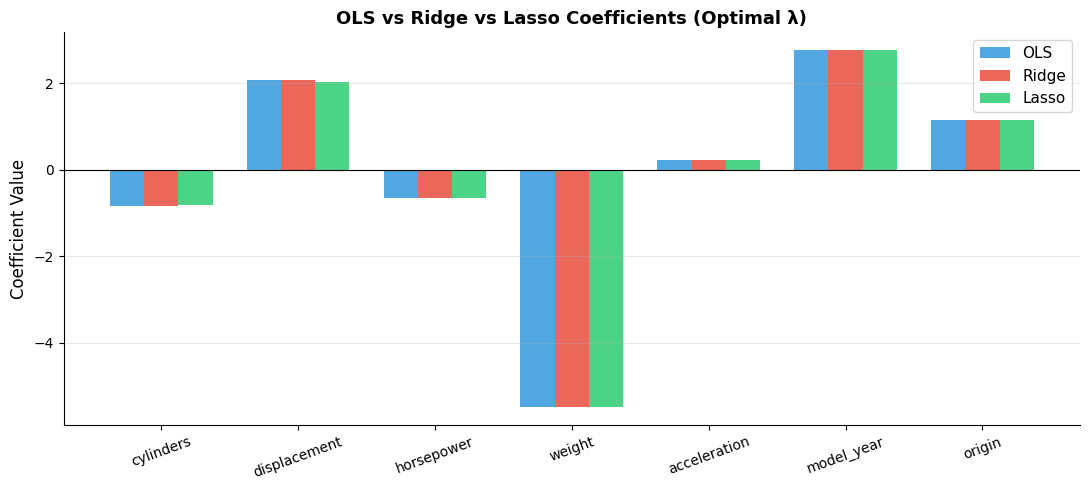

     Feature       OLS     Ridge     Lasso
   cylinders -0.840519 -0.840458 -0.819424
displacement  2.079303  2.079066  2.033503
  horsepower -0.651636 -0.651665 -0.643912
      weight -5.492050 -5.491873 -5.478332
acceleration  0.222014  0.221977  0.219249
  model_year  2.762119  2.762101  2.760591
      origin  1.147316  1.147304  1.142579


In [21]:
# Compare coefficients at optimal lambda
ridge_opt = Ridge(alpha=opt_ridge_alpha).fit(X_scaled, y)
lasso_opt = Lasso(alpha=opt_lasso_alpha, max_iter=10000).fit(X_scaled, y)
ols       = LinearRegression().fit(X_scaled, y)

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'OLS':     ols.coef_,
    'Ridge':   ridge_opt.coef_,
    'Lasso':   lasso_opt.coef_
})

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(feature_cols))
w = 0.25
ax.bar(x-w,  coef_df['OLS'],   w, label='OLS',   color='#3498DB', alpha=0.85)
ax.bar(x,    coef_df['Ridge'], w, label='Ridge',  color='#E74C3C', alpha=0.85)
ax.bar(x+w,  coef_df['Lasso'], w, label='Lasso',  color='#2ECC71', alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=20)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('OLS vs Ridge vs Lasso Coefficients (Optimal λ)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('./visualizations/coefficient_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(coef_df.to_string(index=False))

### 3c. Principal Component Analysis (PCA) + Partial Least Squares (PLS)


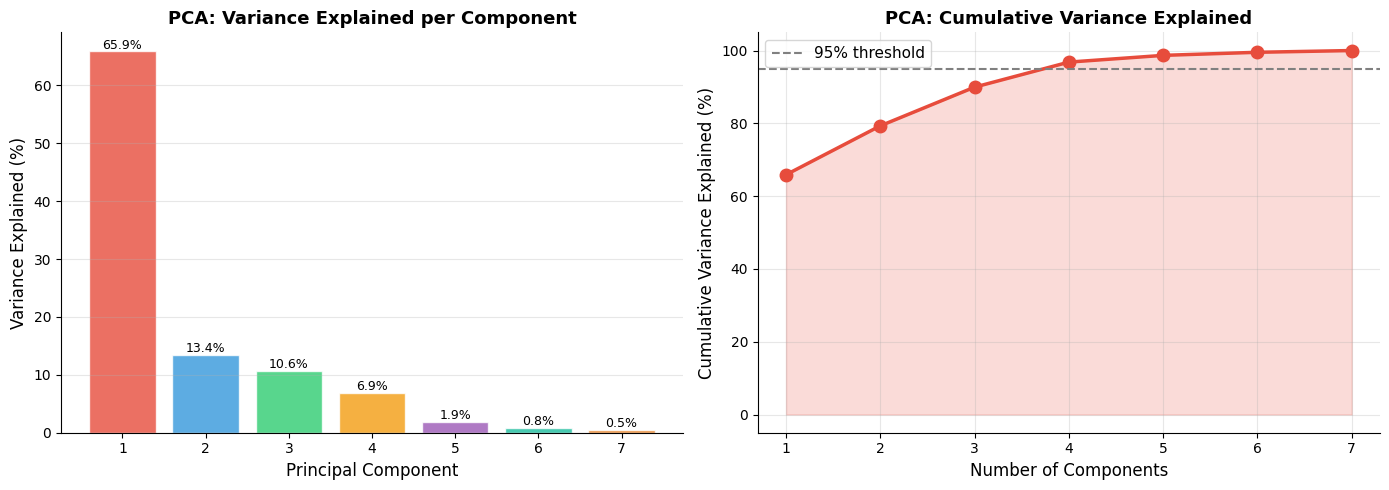

PC1: 65.89%  (cumulative: 65.89%)
PC2: 13.43%  (cumulative: 79.32%)
PC3: 10.63%  (cumulative: 89.95%)
PC4: 6.88%  (cumulative: 96.82%)
PC5: 1.85%  (cumulative: 98.67%)
PC6: 0.85%  (cumulative: 99.52%)
PC7: 0.48%  (cumulative: 100.00%)


In [22]:
# PCA — variance explained
pca_full = PCA(n_components=7)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(range(1, 8), explained * 100, color=COLORS, alpha=0.8, edgecolor='white')
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Variance Explained (%)', fontsize=12)
ax.set_title('PCA: Variance Explained per Component', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 8))
for bar, val in zip(bars, explained * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.plot(range(1, 8), cumulative * 100, 'o-', color='#E74C3C', lw=2.5, ms=9)
ax.axhline(95, color='gray', ls='--', lw=1.5, label='95% threshold')
ax.fill_between(range(1, 8), cumulative * 100, alpha=0.2, color='#E74C3C')
ax.set_xlabel('Number of Components', fontsize=12)
ax.set_ylabel('Cumulative Variance Explained (%)', fontsize=12)
ax.set_title('PCA: Cumulative Variance Explained', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 8))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./visualizations/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

for i, (ev, cum) in enumerate(zip(explained, cumulative)):
    print(f'PC{i+1}: {ev*100:.2f}%  (cumulative: {cum*100:.2f}%)')

In [23]:
# PCR — MSE vs number of components
kf = KFold(n_splits=10, shuffle=True, random_state=42)
pcr_mses = []
pls_mses = []
n_components_range = range(1, 8)

for n_comp in n_components_range:
    # PCR
    pca_pipe = Pipeline([
        ('pca', PCA(n_components=n_comp)),
        ('lr',  LinearRegression())
    ])
    mse_pcr = -cross_val_score(pca_pipe, X_scaled, y, cv=kf,
                                scoring='neg_mean_squared_error').mean()
    pcr_mses.append(mse_pcr)
    
    # PLS
    pls = PLSRegression(n_components=n_comp)
    mse_pls = -cross_val_score(pls, X_scaled, y, cv=kf,
                                scoring='neg_mean_squared_error').mean()
    pls_mses.append(mse_pls)

# OLS baseline
ols_mse = -cross_val_score(LinearRegression(), X_scaled, y, cv=kf,
                            scoring='neg_mean_squared_error').mean()

print(f'OLS (full model) CV MSE: {ols_mse:.3f}')
for i, (p, pl) in enumerate(zip(pcr_mses, pls_mses)):
    print(f'n_comp={i+1}: PCR={p:.3f}  PLS={pl:.3f}')

OLS (full model) CV MSE: 11.452
n_comp=1: PCR=16.988  PLS=15.728
n_comp=2: PCR=16.942  PLS=12.818
n_comp=3: PCR=13.247  PLS=12.109
n_comp=4: PCR=13.164  PLS=11.720
n_comp=5: PCR=12.655  PLS=11.630
n_comp=6: PCR=11.796  PLS=11.456
n_comp=7: PCR=11.452  PLS=11.452


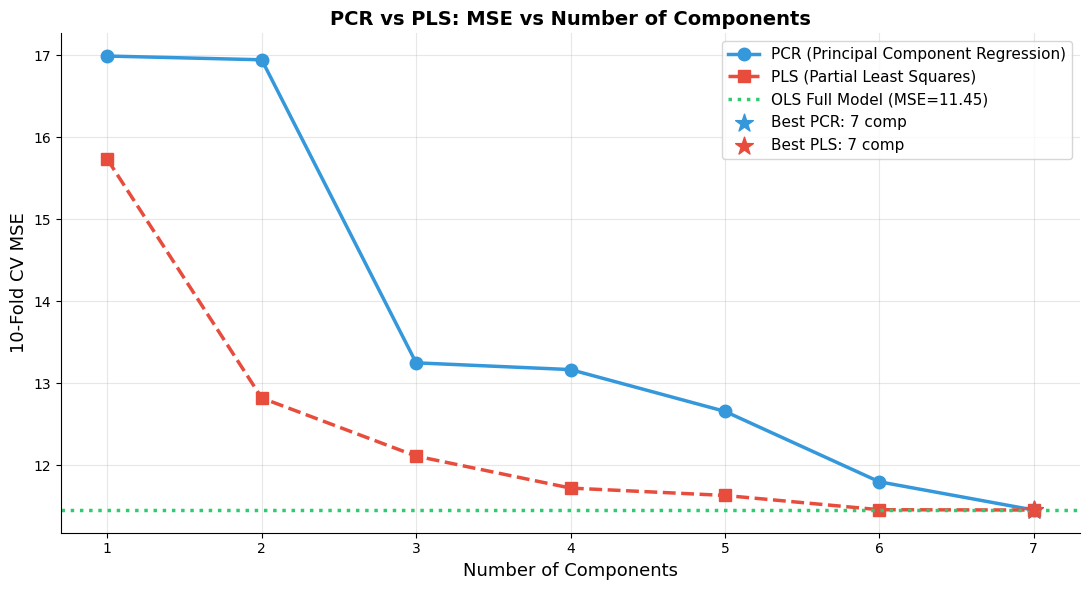

In [24]:
# ─── PCR vs PLS vs OLS ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(list(n_components_range), pcr_mses, 'o-',  color='#3498DB', lw=2.5, ms=9, label='PCR (Principal Component Regression)')
ax.plot(list(n_components_range), pls_mses, 's--', color='#E74C3C', lw=2.5, ms=9, label='PLS (Partial Least Squares)')
ax.axhline(ols_mse, color='#2ECC71', ls=':', lw=2.5, label=f'OLS Full Model (MSE={ols_mse:.2f})')

best_pcr = np.argmin(pcr_mses) + 1
best_pls = np.argmin(pls_mses) + 1
ax.scatter([best_pcr], [pcr_mses[best_pcr-1]], color='#3498DB', s=180, zorder=5,
           marker='*', label=f'Best PCR: {best_pcr} comp')
ax.scatter([best_pls], [pls_mses[best_pls-1]],  color='#E74C3C', s=180, zorder=5,
           marker='*', label=f'Best PLS: {best_pls} comp')

ax.set_xlabel('Number of Components', fontsize=13)
ax.set_ylabel('10-Fold CV MSE', fontsize=13)
ax.set_title('PCR vs PLS: MSE vs Number of Components', fontsize=14, fontweight='bold')
ax.set_xticks(list(n_components_range))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./visualizations/pcr_pls_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

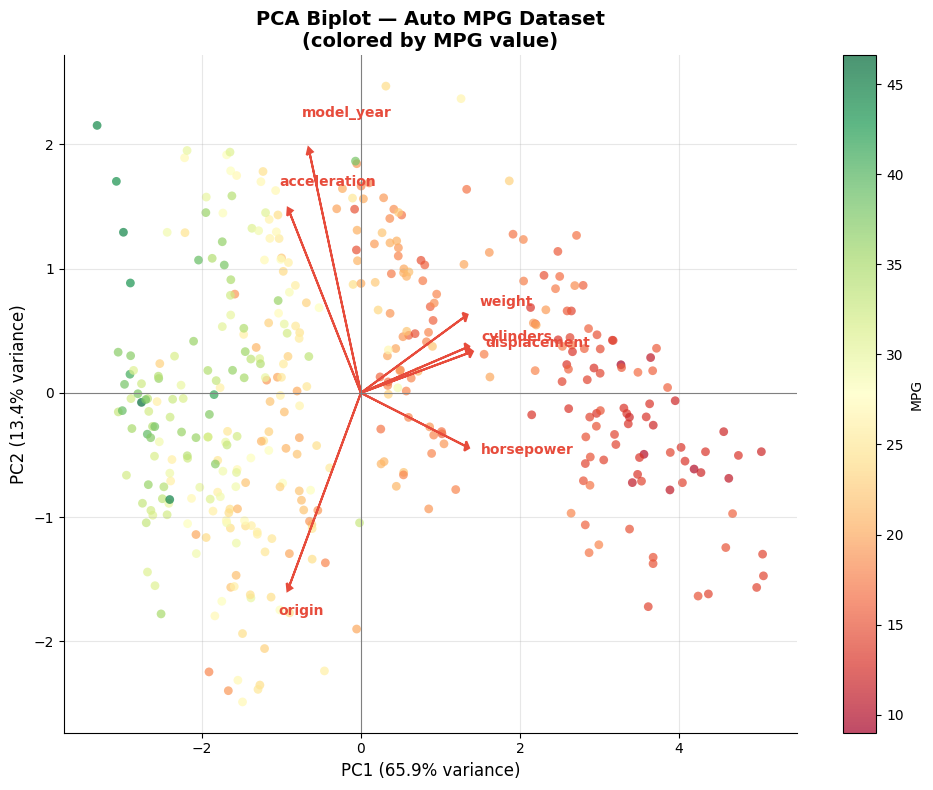

In [25]:
# PCA Biplot — visualize feature loadings on PC1 vs PC2
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y, cmap='RdYlGn', alpha=0.7, s=40, edgecolors='none')
plt.colorbar(sc, ax=ax, label='MPG')

# Loadings
scale = 3
for j, feat in enumerate(feature_cols):
    ax.arrow(0, 0, pca2.components_[0, j]*scale, pca2.components_[1, j]*scale,
             head_width=0.08, head_length=0.05, fc='#E74C3C', ec='#E74C3C', lw=1.5)
    ax.text(pca2.components_[0, j]*scale*1.15, pca2.components_[1, j]*scale*1.15,
            feat, fontsize=10, color='#E74C3C', fontweight='bold')

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Biplot — Auto MPG Dataset\n(colored by MPG value)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='gray', lw=0.8)
plt.tight_layout()
plt.savefig('./visualizations/pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📋 Part 4: Model Comparison Summary


In [26]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

models = {
    'OLS (all features)':   LinearRegression(),
    'OLS (best 4 subset)':  LinearRegression(),
    'Ridge (optimal λ)':    Ridge(alpha=opt_ridge_alpha),
    'Lasso (optimal λ)':    Lasso(alpha=opt_lasso_alpha, max_iter=10000),
    f'PCR ({best_pcr} comp)': Pipeline([('pca', PCA(n_components=best_pcr)), ('lr', LinearRegression())]),
    f'PLS ({best_pls} comp)': PLSRegression(n_components=best_pls)
}

X_best4 = X_scaled[:, best_subset_results[3]['cols']]

results_summary = []
for name, model in models.items():
    X_use = X_best4 if 'best 4' in name else X_scaled
    mse  = -cross_val_score(model, X_use, y, cv=kf, scoring='neg_mean_squared_error').mean()
    rmse = np.sqrt(mse)
    r2   = cross_val_score(model, X_use, y, cv=kf, scoring='r2').mean()
    results_summary.append({'Model': name, 'CV MSE': round(mse, 3),
                             'CV RMSE': round(rmse, 3), 'CV R²': round(r2, 4)})
    print(f'{name:30s}  MSE={mse:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}')

summary_df = pd.DataFrame(results_summary)
print('\n✅ Model comparison complete!')

OLS (all features)              MSE=11.452  RMSE=3.384  R²=0.8085
OLS (best 4 subset)             MSE=11.353  RMSE=3.369  R²=0.8113
Ridge (optimal λ)               MSE=11.452  RMSE=3.384  R²=0.8085
Lasso (optimal λ)               MSE=11.451  RMSE=3.384  R²=0.8085
PCR (7 comp)                    MSE=11.452  RMSE=3.384  R²=0.8085
PLS (7 comp)                    MSE=11.452  RMSE=3.384  R²=0.8085

✅ Model comparison complete!


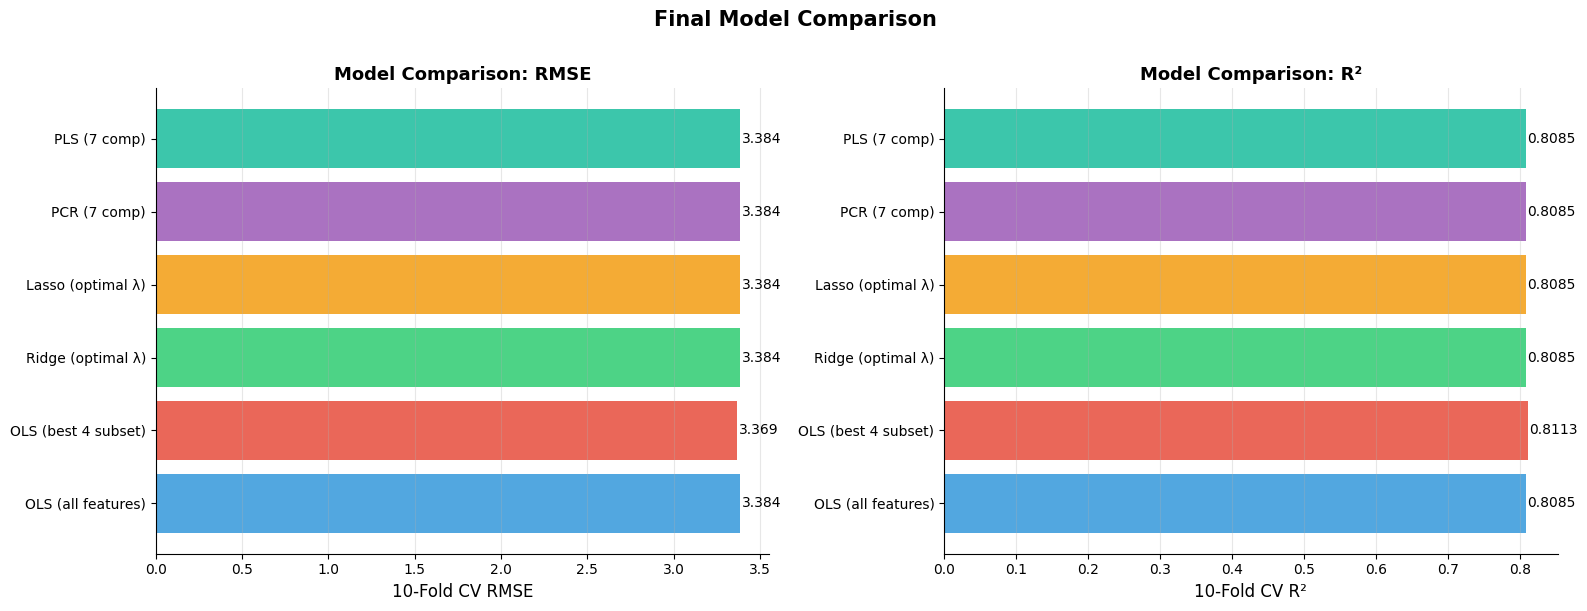

In [30]:
# Summary Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_bar = ['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6','#1ABC9C']
names = [r['Model'] for r in results_summary]

ax = axes[0]
bars = ax.barh(names, [r['CV RMSE'] for r in results_summary], color=colors_bar, alpha=0.85)
ax.set_xlabel('10-Fold CV RMSE', fontsize=12)
ax.set_title('Model Comparison: RMSE', fontsize=13, fontweight='bold')
for bar, val in zip(bars, [r['CV RMSE'] for r in results_summary]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

ax = axes[1]
bars = ax.barh(names, [r['CV R²'] for r in results_summary], color=colors_bar, alpha=0.85)
ax.set_xlabel('10-Fold CV R²', fontsize=12)
ax.set_title('Model Comparison: R²', fontsize=13, fontweight='bold')
for bar, val in zip(bars, [r['CV R²'] for r in results_summary]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Final Model Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./visualizations/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Save results for Streamlit app
import json

results_to_save = {
    'cv_mse': {'k5': cv_results['k5'], 'k10': cv_results['k10'], 'loocv': cv_results['loocv']},
    'bootstrap_mse': bootstrap_mses,
    'bootstrap_std': bootstrap_stds,
    'degrees': degrees,
    'subset_aic':   [r['aic']   for r in best_subset_results],
    'subset_bic':   [r['bic']   for r in best_subset_results],
    'subset_cp':    [r['cp']    for r in best_subset_results],
    'subset_adjr2': [r['adjr2'] for r in best_subset_results],
    'subset_cv_mse': cv_subset_mses,
    'opt_ridge_alpha': opt_ridge_alpha,
    'opt_lasso_alpha': opt_lasso_alpha,
    'pca_explained': list(explained),
    'pcr_mses': pcr_mses,
    'pls_mses': pls_mses,
    'ols_mse': ols_mse,
    'summary': results_summary,
    'feature_cols': feature_cols,
    'ols_coefs': list(ols.coef_),
    'ridge_coefs_opt': list(ridge_opt.coef_),
    'lasso_coefs_opt': list(lasso_opt.coef_)
}

with open('./data/results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

df.to_csv('./data/auto_mpg_clean.csv', index=False)
print('✅ Results saved to ./data/results.json')
print('✅ Clean dataset saved to ./data/auto_mpg_clean.csv')

✅ Results saved to ./data/results.json
✅ Clean dataset saved to ./data/auto_mpg_clean.csv


---
## ✅ Summary

| Method | Key Finding |
|--------|------------|
| **K-Fold CV (K=5,10,LOOCV)** | Polynomial degree 2–3 minimizes CV error; higher degrees overfit |
| **Bootstrap** | Confirms degree 2–3 as optimal; error bars show stability |
| **Best Subset / Forward / Backward** | ~4–5 features sufficient (weight, displacement, model_year, origin, horsepower) |
| **Ridge Regression** | Optimal λ shrinks coefficients without zeroing; best for stable features |
| **Lasso Regression** | Sparse solution; zeroes out weak predictors (cylinders, acceleration) |
| **PCA / PCR** | First 3 PCs explain >95% variance; PCR matches full OLS |
| **PLS** | Slightly better than PCR with fewer components (supervised) |
